In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)


In [3]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return torch.sigmoid(self.output(x))


In [4]:
epochs = 100
batch_size = 64
learning_rate = 0.01
criterion = nn.BCELoss()


In [ ]:
def train_model(optimizer_name):
    torch.manual_seed(0)  
    model = SimpleNN()
    
    if optimizer_name == "Vanilla GD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    losses = []

    for epoch in range(epochs):
        permutation = torch.randperm(X_train.size(0))
        epoch_loss = 0

        for i in range(0, X_train.size(0), batch_size):
            indices = permutation[i:i + batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

    return losses


In [6]:
loss_vanilla = train_model("Vanilla GD")
loss_momentum = train_model("Momentum")
loss_rmsprop = train_model("RMSProp")
loss_adam = train_model("Adam")


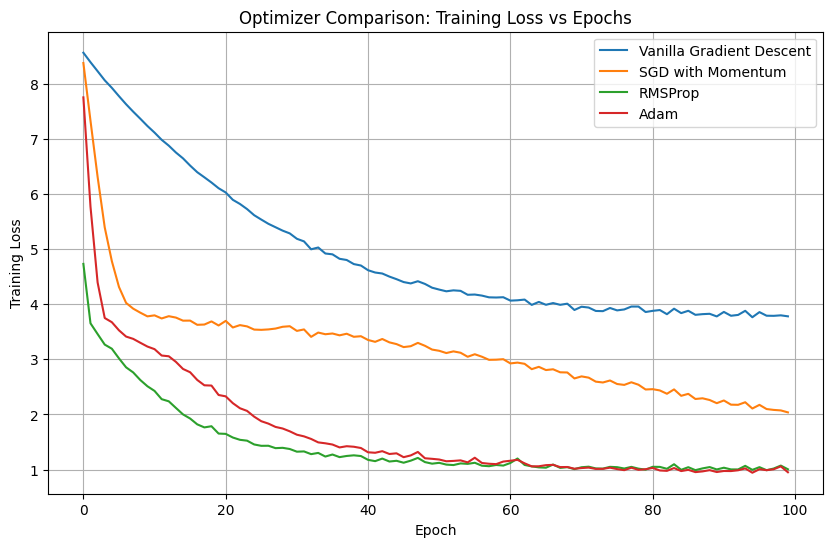

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(loss_vanilla, label="Vanilla Gradient Descent")
plt.plot(loss_momentum, label="SGD with Momentum")
plt.plot(loss_rmsprop, label="RMSProp")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison: Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()
